In [ ]:

import kagglehub
rohitgrewal_loan_approval_dataset_path = kagglehub.dataset_download('rohitgrewal/loan-approval-dataset')

print('Data source import complete.')


100%|██████████| 80.6k/80.6k [00:00<00:00, 15.9MB/s]

Extracting files...
Data source import complete.


In [ ]:
cols_for_count = ['no_of_dependents', 'education', 'self_employed']

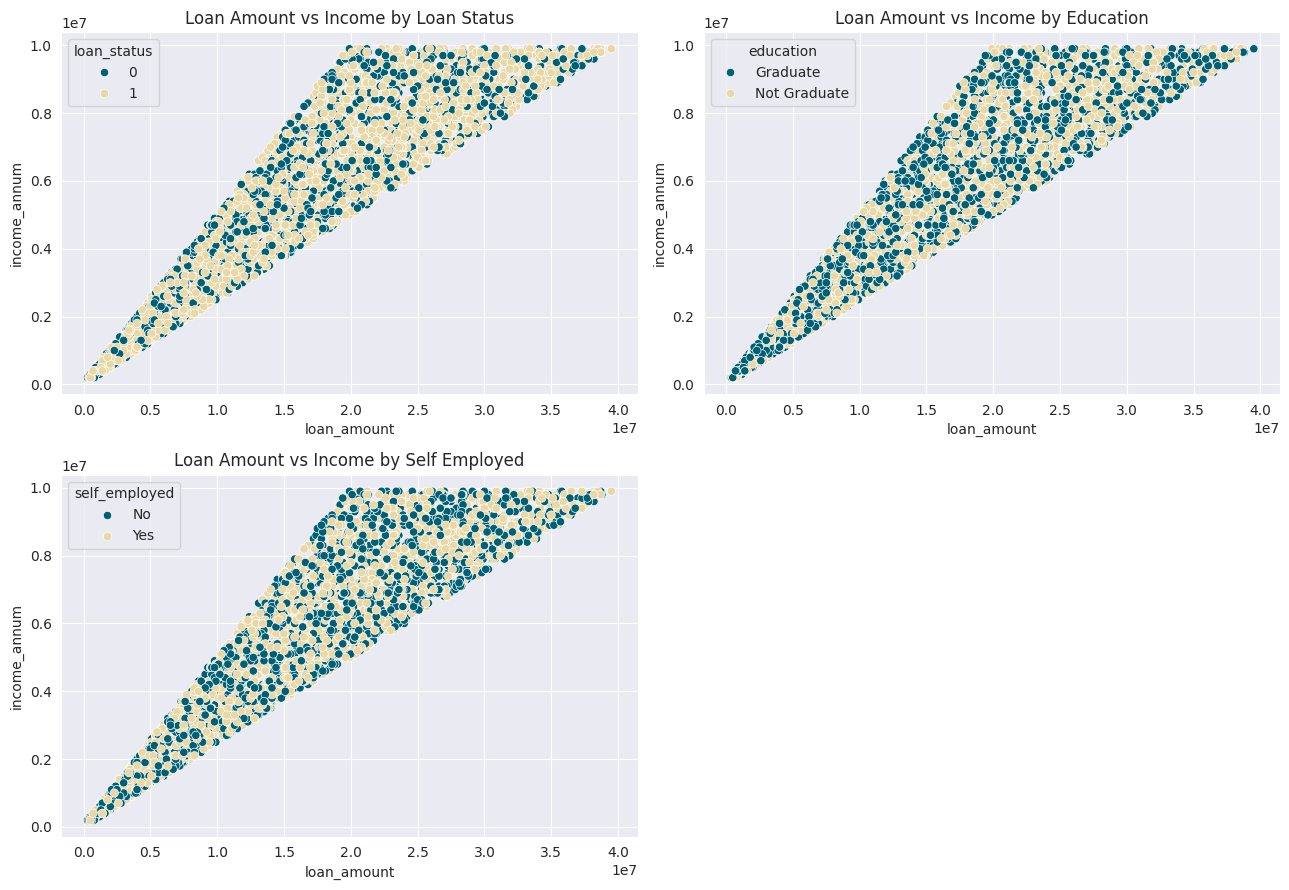

In [ ]:
#data visualization
custom_palette = ["#005F73", "#E9D8A6"]


plt.figure(figsize=(13, 9))

hue_columns = ["loan_status", "education", "self_employed"]

for i, column in enumerate(hue_columns, 1):
    plt.subplot(2, 2, i)

    sns.scatterplot(
        x="loan_amount",
        y="income_annum",
        hue=column,
        palette=custom_palette,
        data=df
    )

    plt.title(f"Loan Amount vs Income by {column.replace('_', ' ').title()}")

plt.tight_layout()
plt.show()

In [ ]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)



import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

1. Loading Dataset...
Using Colab cache for faster access to the 'loan-approval-dataset' dataset.

DATA EXPLORATION & INSPECTION

---> FIRST 5 ROWS (df.head):


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected



---> LAST 5 ROWS (df.tail):


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved
4268,4269,1,Graduate,No,9200000,29700000,10,607,17800000,11800000,35700000,12000000,Approved



---> DATA TYPES & INFO (df.info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1   no_of_dependents           4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memo

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07



2. Cleaning Data and Engineering Features...
3. Training High-Performance XGBoost Classifier...

MODEL ACCURACY: 98.48%

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.98      0.97      0.98       318
    Approved       0.99      0.99      0.99       536

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



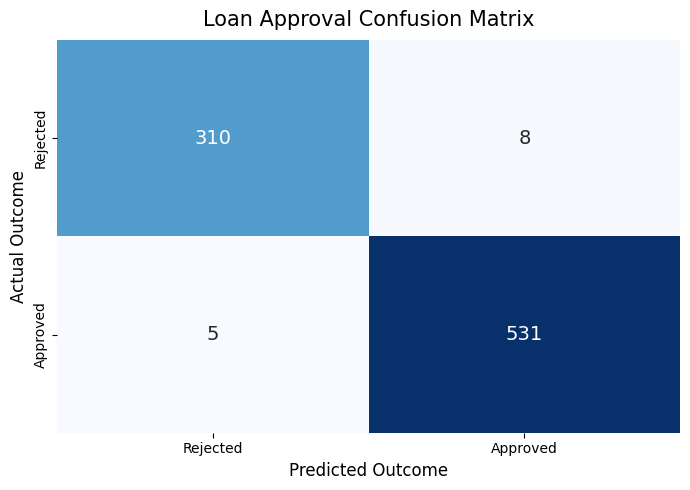

In [ ]:
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("1. Loading Dataset...")
# Download dataset via Kagglehub
path = kagglehub.dataset_download("rohitgrewal/loan-approval-dataset")
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

# ==========================================
# 2. BASIC DATA EXPLORATION (EDA)
# ==========================================
print("\n" + "="*50)
print("DATA EXPLORATION & INSPECTION")
print("="*50)

print("\n---> FIRST 5 ROWS (df.head):")
display(df.head()) # Use print(df.head()) if display() throws an error in your environment

print("\n---> LAST 5 ROWS (df.tail):")
display(df.tail())

print("\n---> DATA TYPES & INFO (df.info):")
df.info()

print("\n---> MISSING VALUES CHECK:")
print(df.isnull().sum())

print("\n---> STATISTICAL SUMMARY (df.describe):")
display(df.describe())

# ==========================================
# 3. DATA CLEANING & LEAKAGE PREVENTION
# ==========================================
print("\n2. Cleaning Data and Engineering Features...")
# Strip hidden spaces from columns and text data (Crucial for this dataset)
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].str.strip()

# DATA LEAKAGE PREVENTION: Drop 'loan_id'
if 'loan_id' in df.columns:
    df = df.drop('loan_id', axis=1)

# Encode Target Variable (Approved/Rejected)
le = LabelEncoder()
df['loan_status'] = le.fit_transform(df['loan_status'])
df['loan_status'] = 1 - df['loan_status'] # Formats it so Approved = 1, Rejected = 0

# Encode text features (e.g., converting "Graduate" to numbers)
categorical_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# ==========================================
# 4. SPLIT DATA & TRAIN MODEL
# ==========================================
X = df_encoded.drop('loan_status', axis=1)
y = df_encoded['loan_status']

# Split into 80% Training and 20% Testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("3. Training High-Performance XGBoost Classifier...")
model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
model.fit(X_train, y_train)

# ==========================================
# 5. EVALUATE & VISUALIZE
# ==========================================
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("\n" + "="*40)
print(f"MODEL ACCURACY: {accuracy * 100:.2f}%")
print("="*40)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Rejected', 'Approved']))

# Generate a single, clean Confusion Matrix
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Rejected', 'Approved'],
            yticklabels=['Rejected', 'Approved'],
            annot_kws={"size": 14}) # Make numbers larger and easier to read
plt.title('Loan Approval Confusion Matrix', fontsize=15, pad=10)
plt.xlabel('Predicted Outcome', fontsize=12)
plt.ylabel('Actual Outcome', fontsize=12)
plt.tight_layout()
plt.show()